*Notes*


Use openCV and contours to make bounding box of the useful part of the image

stretch x and y axis with same ration to maintain aspect ratio
(prevents affecting taller than wide/wider than tall  measurements etc)

add padding (probably black) to make all images the same resolution

cv2.THRESH_BINARY returns the image in binary form (white or black)

ROI: region of interest

https://stackoverflow.com/questions/49466033/resizing-image-and-its-bounding-box/49468149 -- resizing guide
https://www.youtube.com/watch?v=9FCw1xo_s0I -- bounding box guide

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt


In [2]:
image = cv2.imread(os.path.join('..', 'data', '178.png'))




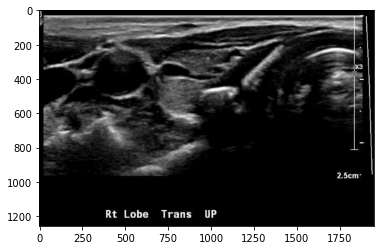

In [3]:
plt.imshow(image)

In [4]:
grey_image=cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

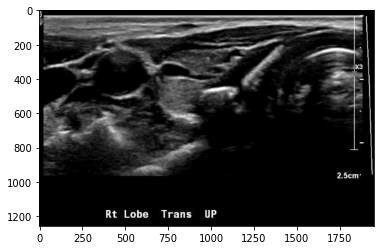

In [5]:
plt.imshow(grey_image,cmap='gray')

In [6]:
blur=cv2.GaussianBlur(grey_image,(3,3),0)

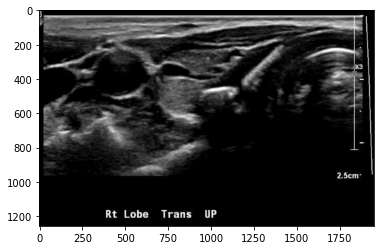

In [7]:
plt.imshow(blur,cmap='gray')

In [8]:
thresh= cv2.threshold(blur,10,255,cv2.THRESH_BINARY)[1]

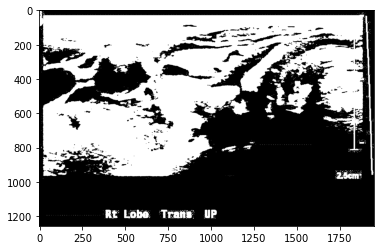

In [9]:
plt.imshow(thresh,cmap='gray')

In [10]:
kernel=cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))

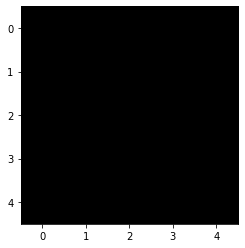

In [11]:
plt.imshow(kernel,cmap='gray')

In [12]:

opening=cv2.morphologyEx(thresh,cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

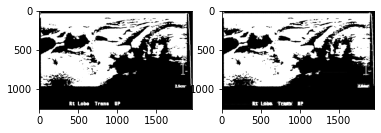

In [13]:
f, axarr = plt.subplots(1,2)
axarr[0].imshow(opening,cmap='gray')
axarr[1].imshow(closing,cmap='gray')



In [14]:
#Forms contours
cnts=cv2.findContours(opening,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
cnts=cnts[0] if len(cnts)==2 else cnts[1]

might have to use open/ close depending on

In [15]:
#makes bounding box using contours
cnts = sorted(cnts, key=lambda c: cv2.contourArea(c), reverse=True)
for c in cnts[:1]:
    x,y,w,h = cv2.boundingRect(c)
    cv2.rectangle(image,(x,y), (x+w,y+h),(36,255,12),2) 

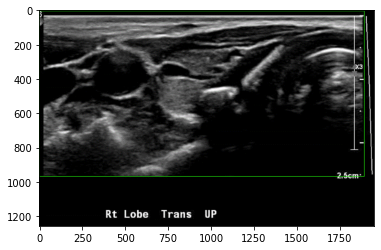

In [16]:
plt.imshow(image)

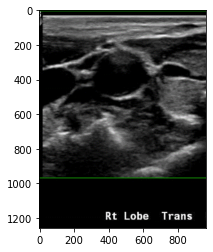